In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from datetime import timedelta
import matplotlib.dates as mdates
from scipy import interpolate, integrate
from pandas.tseries.frequencies import to_offset
import datetime
import matplotlib as mpl
import os
#----------------------------------------------------------------------
from cloudnetpy.products import generate_lwc
from cloudnetpy.products import generate_der
from cloudnetpy.products.der import Parameters
#----------------------------------------------------------------------

In [2]:
PATH_CLASS        = '../../data/classification/'
PATH_CATE         = '../../data/categorize/'
PATH_FIG          = '../figures/'
PATH_CLOUDNET_LWC = '../../retrievals_cloudnet/liquid_cloud/lwc/'
PATH_CLOUDNET_DER = '../../retrievals_cloudnet/liquid_cloud/der/'

In [3]:
import os
import pandas as pd

def groupSequence(lst):
    res = [[lst[0]]]
 
    for i in range(1, len(lst)):
        if lst[i-1]+1 == lst[i]:
            res[-1].append(lst[i])
 
        else:
            res.append([lst[i]])
    return res

class Intersection_products:
    def __init__(self,
                 path_class,
                 path_radar):
       
        classification_files = {}
        for file in os.listdir(path_class):
            if file.endswith("classification.nc"):
                classification_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
       
        var_files = {}
        for file in os.listdir(path_radar):
            if file.endswith("categorize.nc"):
                var_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
        
        #mwr_files = {}
        #for file in os.listdir(path_mwr):
        #    if file.endswith(".nc"):
        #        mwr_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
                
        classSet = set(classification_files)
        radarSet = set(var_files)
        #mwrSet   = set(mwr_files)

        intersec_products = [] 
        for date in classSet.intersection(radarSet):
            intersec_products.append(date)
    
        self.var_files            = var_files  # dict 
        self.classification_files = classification_files # dict
        self.dates                = sorted(intersec_products)
        
class HMmodel:
    def __init__(self,
                 lwp,
                 h,
                 z,
                 v=8.7,
                 rw=1e6):
        
        self.cloud_lwp = lwp # liquid water path
        self.cloud_z   = h   # cloud thickeness
        self.radar_ze  = z
        self.nu        = v
        self.rho_w     = rw
        self.k_nv      = (v+3)*(v+4)*(v+5)/( v*(v+1)*(v+2) ) 
        self.k_rv      = (v+2)/( (v+3)*(v+4)*(v+5) )**(1./3.)
        
    def get_num(self):
        # droplet concentration in cm^-3
        #print(integrate.trapz(np.sqrt(self.radar_ze), self.cloud_z))
        # ( g m^-2 / ( g m^-3 mm^3 m^-3/2 * m )  )^2 
        # ( m^3/2 mm^-3 )^2
        #  m^3 (10^-3 m)^-6
        #  m^3 10^-18 m^-6 
        # 10-18 m^-3
        # um^-3
        # To convert from um^-3 to cm^-3: 10^12 * (um^-3) = cm^-3
        return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2
        #return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.nansum(np.sqrt(self.radar_ze))*30 ) )**2
    
    def get_re(self):
        # (  g m^-3 mm^3 m^-3/2 * m / ( g m^-2)  )^1/3 mm m^-1/3
        # (  mm^3 m^-3/2  )^1/3 mm m^-1/2
        # (  mm m^-1/2  ) mm m^-1/2
        # (  mm^2 m^-1
        # (  10^-6 m^2 m^-1 )
        # ( 10^-6 m ) = um
        #print(  ( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)  ) 
        return self.k_rv*( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)
        


class Cloud_filters:
    def __init__(self, df_class, cloud_type):
        
        self.classification = df_class # Dataframe
        self.height         = df_class.columns
        self.cloud          = cloud_type
    
    def quantile_nearest_pixel(self, specie):
        ''' description '''
        row_cloud, col_cloud    = np.where(self.classification == self.cloud)
        row_specie, col_specie  = np.where(self.classification == specie)
        intersection            = np.intersect1d(row_cloud, row_specie) # Temporal index with in Dataframe with coexistence of cloud type and especie
                                                                        # Specie could be ice, rain, aerosol etc....
        no_candidate            = -1.0*self.classification.shape[1]
        dz_bellow               = []
        dz_above                = []
        for i_time in intersection: 
            sequence_cloud  = groupSequence( col_cloud[row_cloud == i_time] ) # liquid pixels sequancies  
            sequence_specie = groupSequence( col_specie[row_specie == i_time] ) 
            
            for cloud_thickness in sequence_cloud:
                
                dbl = no_candidate  # delta bellow the cloud
                ibl = np.nan        # pixel bellow the cloud
        
                dab = abs(no_candidate) # delta bellow the cloud
                iab = np.nan            # pixel bellow the cloud
                
                for specie_thickness in sequence_specie:
            
                    dnew = specie_thickness[-1] - cloud_thickness[0] # new delta bellow the cloud
                    if dnew < 0 and dnew > dbl:
                        dbl = dnew
                        ibl = specie_thickness[-1]
                        
                    dnew = specie_thickness[0] - cloud_thickness[-1] # new delta above the cloud
                    if dnew > 0 and dnew < dab:
                        dab = dnew
                        iab = specie_thickness[0]
         
                if not np.isnan(ibl) and not np.isnan(iab):
                    dz_bellow.append( self.height[cloud_thickness[0]] - self.height[ibl] )
                    dz_above.append( self.height[iab] - self.height[cloud_thickness[-1]] )
                elif not np.isnan(ibl):
                    dz_bellow.append( self.height[cloud_thickness[0]] - self.height[ibl] )
                elif not np.isnan(iab):
                    dz_above.append( self.height[iab] - self.height[cloud_thickness[-1]] )
                  
        return dz_bellow, dz_above
        
    def filtering_specie(self, specie, dzb_max, dzt_max):
        ''' description '''
        row_cloud, col_cloud    = np.where(self.classification == self.cloud)
        row_specie, col_specie  = np.where(self.classification == specie)
        intersection            = np.intersect1d(row_cloud, row_specie) # Temporal index with in Dataframe with coexistence of cloud type and especie
        
        if intersection.any():                                                                # Specie could be ice, rain, aerosol etc....
            no_candidate        = -1.0*self.classification.shape[1]
            for i_time in intersection: 
                sequence_cloud  = groupSequence( col_cloud[row_cloud == i_time] ) # liquid pixels sequancies  
                sequence_specie = groupSequence( col_specie[row_specie == i_time] ) 
            
                for cloud_thickness in sequence_cloud:
                    dbl = no_candidate      # delta bellow the cloud
                    dab = abs(no_candidate) # delta bellow the cloud
                    ibl = np.nan            # pixel bellow the cloud
                    iab = np.nan            # pixel bellow the cloud
                
                    for specie_thickness in sequence_specie:
                        dnew = specie_thickness[-1] - cloud_thickness[0] # new delta bellow the cloud
                        if dnew < 0 and dnew > dbl:
                            dbl = dnew
                            ibl = specie_thickness[-1]
                        
                        dnew = specie_thickness[0] - cloud_thickness[-1] # new delta above the cloud
                        if dnew > 0 and dnew < dab:
                            dab = dnew
                            iab = specie_thickness[0]
        
                    if not np.isnan(ibl) and not np.isnan(iab):
                        #print("have ice bellow and above liquid cloud")
                        dzb = self.height[cloud_thickness[0]] - self.height[ibl]
                        dzt = self.height[iab] - self.height[cloud_thickness[-1]]
                        #print(dzb)
                        if dzb <= dzb_max or dzt <= dzt_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                    elif not np.isnan(ibl):
                        dzb = self.height[cloud_thickness[0]] - self.height[ibl]
                        #print(dzb)
                        if dzb <= dzb_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                    elif not np.isnan(iab):
                        dzt = self.height[iab] - self.height[cloud_thickness[-1]]
                        if dzt <= dzt_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan

    def filtering_dz(self, dz_min):
        """ description """
        #filtered_dz = self.classification.copy()
        row, col        = np.where(self.classification == self.cloud)
        row_unique      = np.unique(row)
        
        if row_unique.any():
            for i_time in row_unique:
                sequence_z = groupSequence( col[row==i_time] )
                for group_z in sequence_z:
                    dz = self.height[group_z].max() - self.height[group_z].min()
                    if dz < dz_min:
                        self.classification.iloc[i_time,group_z] = np.nan

    def filtering_dt(self, dt_min):
        """ description """
        #filtered_dt = self.classification.copy()
        row, col        = np.where(self.classification == self.cloud)
        row_unique      = np.unique(row)
        
        if row_unique.any():
            sequence_time   = groupSequence(row_unique)
            for group_t in sequence_time:
                dt = self.classification.index[group_t].max() - self.classification.index[group_t].min()
                if dt < datetime.timedelta(minutes=dt_min):
                    for i_time in group_t:
                        sequence_z = groupSequence( col[row==i_time] )
                        for group_z in sequence_z:
                            self.classification.iloc[i_time,group_z] = np.nan

    def filtered_ze(self, ze):
        """ description """
        #return self.reflectivity.where(self.classification == self.cloud, np.nan)
        return ze.where(self.classification == self.cloud, np.nan)
        
        #for group_t in sequence_time:
        #    dt = self.classification.index[group_t].max() - self.classification.index[group_t].min()
        #    print(self.classification.index[group_t].min(),
        #          self.classification.index[group_t].max())
        #    #if dt < datetime.timedelta(minutes=m):
        #    for i_time in group_t:
        #        sequence_z = groupSequence( col[row==i_time] )
        #        #n = len(sequence_z)
        #        #if n > 1:
        #        #    print(self.classification.index[i_time])
        #        for group_z in sequence_z:
        #            z  = filtered_limits.columns[group_z]
        #            dz = z[-1] - z[0]
        #            #print(sum(np.diff(sequence_z) > 60))
        #            #print(self.classification.index[i_time], dt < datetime.timedelta(minutes=m))
        #            if dz < dz_min or dt < datetime.timedelta(minutes=m):
        #                #print(dz)
        #                filtered_limits.iloc[i_time,group_z] = np.nan 
        
        #return filtered_limits

class Radar:
    def __init__(self,
                 f,
                 out,
                 ins_info,
                 out_info,
                 z, 
                 thick,
                 r,
                 d,
                 dp,
                 mrf,
                 t,
                 pha,
                 l):
        
        self.input_filename  = f
        self.output_filename = out
        self.instrument_info = ins_info
        self.output_info     = out_info
        self.height          = z
        self.thickness       = thick
        self.reff            = r
        self.dist            = d
        self.distparam       = dp
        self.max_rad_factor  = mrf
        self.temp            = t
        self.phase           = pha
        self.lwc             = l
        
    def build_system_info(self):
        self.system_info = [self.instrument_info, self.output_info]
        
    def build_cloud_info(self):
        self.cloud_info  = np.concatenate(([self.height],
                                 [self.thickness], 
                                 [self.reff],
                                 [self.dist], 
                                 [self.distparam],
                                 [self.max_rad_factor],
                                 [self.temp],
                                 [self.phase],
                                 [self.lwc]), axis=0).transpose()
    def write_input(self):
        self.build_system_info()
        self.build_cloud_info()
        
        # instrument and output information:
        lines = []
        for lin in self.system_info:
            lines.append('\t'.join(map(str, lin)))

        # cloud information 
        for i in range(self.cloud_info.shape[0]):
            lines.append('\t'.join(self.cloud_info[i,:]))
        
        with open(self.input_filename, 'w') as f:
            for line in lines:
                f.write(line)
                f.write('\n')
    
    def run(self):
        os.system("ssradar "+ self.input_filename + ">" + self.output_filename) # it works because the output
                                                                        # is a .txt file
    def get_output(self):
        return np.loadtxt(self.output_filename, skiprows=8)
    
    def simulated_signal_change_nu(self, z, nu):
        """ description """
        self.height    = z
        self.distparam = np.array(z.size*[nu])
        self.write_input()
        self.run()
        self.result    = self.get_output()
        return self.result[:,3] # reflectivity
    
    def simulated_signal_change_re(self, re):
        """ description """
        self.reff   = re
        self.write_input()
        self.run()
        return self.get_output() # reflectivity
    
    def simulated_signal_change_re_nu(self, re, nu):
        """ description """
        self.reff      = re
        self.distparam = nu
        self.write_input()
        self.run()
        return self.get_output() # reflectivity
        

In [4]:
cloudnet_example = Intersection_products(PATH_CLASS, PATH_CATE)
start_date       = min(cloudnet_example.dates)
end_date         = max(cloudnet_example.dates)

for date in cloudnet_example.dates:
    print(date.date(), cloudnet_example.var_files[date])
    
#res = (cloudnet_example.dates == pd.Timestamp('2021-04-25')).argmax()

2021-04-01 20210401_granada_categorize.nc
2021-04-02 20210402_granada_categorize.nc
2021-04-03 20210403_granada_categorize.nc
2021-04-04 20210404_granada_categorize.nc
2021-04-05 20210405_granada_categorize.nc
2021-04-06 20210406_granada_categorize.nc
2021-04-07 20210407_granada_categorize.nc
2021-04-08 20210408_granada_categorize.nc
2021-04-09 20210409_granada_categorize.nc
2021-04-10 20210410_granada_categorize.nc
2021-04-11 20210411_granada_categorize.nc
2021-04-12 20210412_granada_categorize.nc
2021-04-13 20210413_granada_categorize.nc
2021-04-14 20210414_granada_categorize.nc
2021-04-15 20210415_granada_categorize.nc
2021-04-16 20210416_granada_categorize.nc
2021-04-17 20210417_granada_categorize.nc
2021-04-18 20210418_granada_categorize.nc
2021-04-19 20210419_granada_categorize.nc
2021-04-20 20210420_granada_categorize.nc
2021-04-21 20210421_granada_categorize.nc
2021-04-22 20210422_granada_categorize.nc
2021-04-23 20210423_granada_categorize.nc
2021-04-24 20210424_granada_catego

In [5]:
date_complete = pd.date_range( start=start_date, end=end_date )
i = 0
for date in date_complete:
    if date == cloudnet_example.dates[i]:
        i+=1
        print(True)
        # Do the script
    else:
        print(False)
        # ADD NaN

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [6]:
date_ex        = cloudnet_example.dates[28] # 29/04/2021
# i = 20 case with diferent resolution 
categorize     = nc.Dataset(PATH_CATE+cloudnet_example.var_files[date_ex])
classification = nc.Dataset(PATH_CLASS+cloudnet_example.classification_files[date_ex])

os.system("rm "+PATH_CLOUDNET_LWC+"*lwc.nc") # remove all lwc files from lwc path 
os.system("rm "+PATH_CLOUDNET_DER+"*der.nc") # remove all der files from der path
generate_lwc(PATH_CATE+cloudnet_example.var_files[date_ex], 
             PATH_CLOUDNET_LWC+cloudnet_example.var_files[date_ex][:17]+'lwc.nc')

params = Parameters(2.0, 100.0e6, 200.0e6, 0.25, 0.1, 5.0e-3)
generate_der(PATH_CATE+cloudnet_example.var_files[date_ex],
             PATH_CLOUDNET_DER+cloudnet_example.var_files[date_ex][:17]+'der.nc', 
             parameters=params)

cloudnet_lwc = nc.Dataset(PATH_CLOUDNET_LWC+cloudnet_example.var_files[date_ex][:17]+'lwc.nc')
cloudnet_der = nc.Dataset(PATH_CLOUDNET_DER+cloudnet_example.var_files[date_ex][:17]+'der.nc')

aux_t = []
for h in categorize['time']:
    aux_t.append( cloudnet_example.var_files[date_ex][:8] + ' ' + str(timedelta(hours=float(h))) )

time_categorize = pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S" ) 

aux_t = []
for h in classification['time']:
    aux_t.append( cloudnet_example.classification_files[date_ex][:8] + ' ' + str(timedelta(hours=float(h))) )

time_class = pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S") 

In [7]:
classification.dimensions['time']

<class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 2880

In [8]:
categorize.dimensions

{'time': <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 2880,
 'height': <class 'netCDF4._netCDF4.Dimension'>: name = 'height', size = 380,
 'model_time': <class 'netCDF4._netCDF4.Dimension'>: name = 'model_time', size = 25,
 'model_height': <class 'netCDF4._netCDF4.Dimension'>: name = 'model_height', size = 137}

In [9]:
categorize.variables

{'Z': <class 'netCDF4._netCDF4.Variable'>
 float32 Z(time, height)
     _FillValue: 9.96921e+36
     units: dBZ
     long_name: Radar reflectivity factor
     comment: This variable has been corrected for attenuation by gaseous attenuation (using the
 thermodynamic variables from a forecast model; see the radar_gas_atten variable) and
 liquid attenuation (using liquid water path from a microwave radiometer; see the
 radar_liquid_atten variable) but rain and melting-layer attenuation has not been corrected.
 Calibration convention: in the absence of attenuation, a cloud at 273 K containing
 one million 100-micron droplets per cubic metre will have a reflectivity of 0 dBZ
 at all frequencies.
     ancillary_variables: Z_error Z_bias Z_sensitivity
     source: RPG-Radiometer Physics RPG-FMCW-94
 unlimited dimensions: 
 current shape = (2880, 380)
 filling on,
 'v': <class 'netCDF4._netCDF4.Variable'>
 float32 v(time, height)
     _FillValue: 9.96921e+36
     units: m s-1
     long_name: D

In [10]:
np.unique( np.diff(categorize['height'][:]) )

masked_array(data=[29.810547, 29.811523, 29.811646, 29.811768, 29.81189 ,
                   29.812012, 29.8125  , 38.20996 , 51.104492, 51.10547 ],
             mask=False,
       fill_value=1e+20,
            dtype=float32)

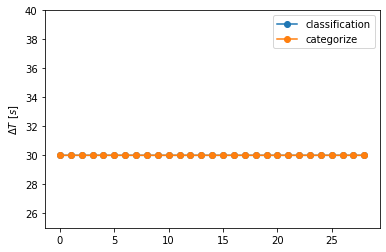

Timestamp('2021-04-29 04:10:14.999199')

In [11]:
a1 = np.diff(classification['time'][:30])*3600
a2 = np.diff(categorize['time'][:30])*3600
#print(a1)
#print(a2)
plt.figure()
plt.plot(a1, '-o',label='classification')
plt.plot(a2, '-o', label='categorize')
plt.ylabel(r'$\Delta T\ [s]$')
plt.legend()
plt.ylim([25, 40])
plt.show()

time_categorize[500]

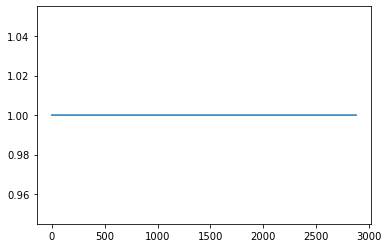

1 1


In [12]:
# Verification of how many time datapoints are equal in radar and classification data
ind = []
s = 0
for t in classification['time']:
    a = np.where(t==categorize['time'])[0]
    if a.size > 0 and a.size == 1:
        ind.append(a[0]) #indexes of coincidency 
        #print("achou")
        s+=1
ind    = np.array(ind, int)
ind_dif=np.diff(ind)
plt.figure()
plt.plot(ind_dif)
plt.show()

print(min(ind_dif), max(ind_dif))

In [13]:
# Verification of how many time datapoints are equal in radar and classification data
s = 0
equal_time = []
for t in time_class:
    if t in time_categorize:
        equal_time.append(t)
        s+=1
print("Equal time index (between class and radar) = %d"%(s))

Equal time index (between class and radar) = 2880


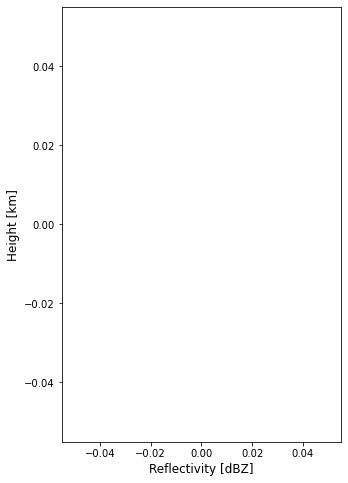

In [14]:
t = 500
fig = plt.figure(figsize=[5, 8])
ax1 = plt.subplot()

colormesh = plt.plot(categorize['Z'][t,:], categorize['height'][:]/1000, marker='o')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Reflectivity [dBZ]')
plt.show()

In [15]:
dfnew_cb             = pd.DataFrame(data=classification['cloud_base_height_amsl'][:], 
                                        index=time_class )
dfnew_ct             = pd.DataFrame(data=classification['cloud_top_height_amsl'][:],
                                        index=time_class )
dfnew_reflectivity   = pd.DataFrame(data=categorize['Z'][:],
                                        index=time_categorize,
                                        columns=categorize['height'][:])
dfnew_lwp            = pd.DataFrame(data=categorize['lwp'][:], 
                                        index=time_categorize )
dfnew_classification = pd.DataFrame(data=classification['target_classification'][:],
                                        index=time_class,
                                        columns=classification['height'][:])
aux_classification = pd.DataFrame(data=np.where( (dfnew_classification != 1)\
                                                & (dfnew_classification != 2)\
                                                & (dfnew_classification != 4),
                                                np.NaN, 
                                                dfnew_classification),
                                  index=dfnew_classification.index,
                                  columns=dfnew_classification.columns)

dfnew_cloudnet_lwc = pd.DataFrame(data=1.0e3*cloudnet_lwc['lwc'][:],
                                  index=time_categorize,
                                  columns=cloudnet_lwc['height'][:]) # g m^-3
dfnew_cloudnet_der = pd.DataFrame(data=1.0e6*cloudnet_der['der'][:],
                                    index=time_categorize,
                                    columns=cloudnet_der['height'][:]) # um

/home/matheustolen/.conda/envs/matheustolenenv/lib/python3.9/site-packages/numpy/ma/core.py:1013: RuntimeWarning: overflow encountered in multiply
  result = self.f(da, db, *args, **kwargs)


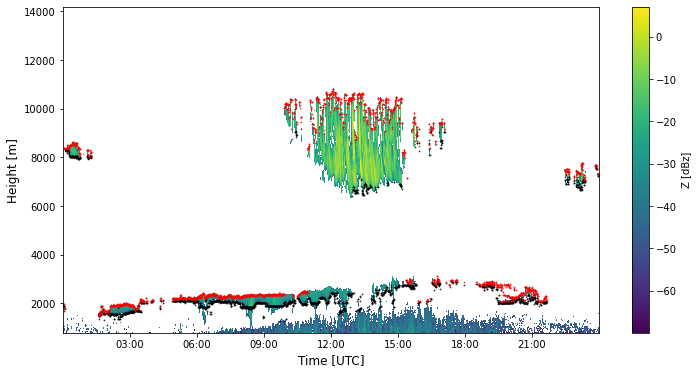

In [16]:
fig = plt.figure(figsize=[12, 6])
#fig = plt.figure()
ax1 = plt.subplot()

colormesh = plt.pcolormesh(time_categorize, categorize['height'][:], np.transpose(categorize['Z'][:]),
                          cmap='viridis',
                          shading='nearest')
plot1 = plt.scatter(time_class, classification['cloud_base_height_amsl'][:], s=1, c='black', alpha=.7, marker='*')
plot2 = plt.scatter(time_class, classification['cloud_top_height_amsl'][:], s=1, c='red', alpha=.7, marker='*')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [m]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

## Rain and Drizzle points removing 

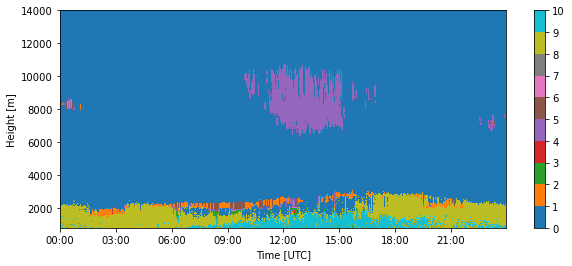

In [17]:
hour_s = 0
hour_e = 23
z_min  = dfnew_classification.columns.min()  # m
z_max  = 14000 # m

fig, axs = plt.subplots(figsize=(10, 4))

f1 = axs.pcolormesh(dfnew_classification.index, 
                    dfnew_classification.columns, 
                    np.transpose(dfnew_classification),
                    cmap='tab10')

fig.colorbar(f1, ax=axs, ticks=list(range(11)))
#cbar.set_ticks([mn,md,mx])

axs.set_ylabel(r'Height [m]')
axs.set_ylim([z_min,z_max])
axs.set_xlabel(r'Time [UTC]')

axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs.set_xlim([dfnew_classification.index.date[0] + pd.DateOffset(hour=hour_s), 
              dfnew_classification.index.date[0] + pd.DateOffset(hour=hour_e, minute=59)])
plt.show()

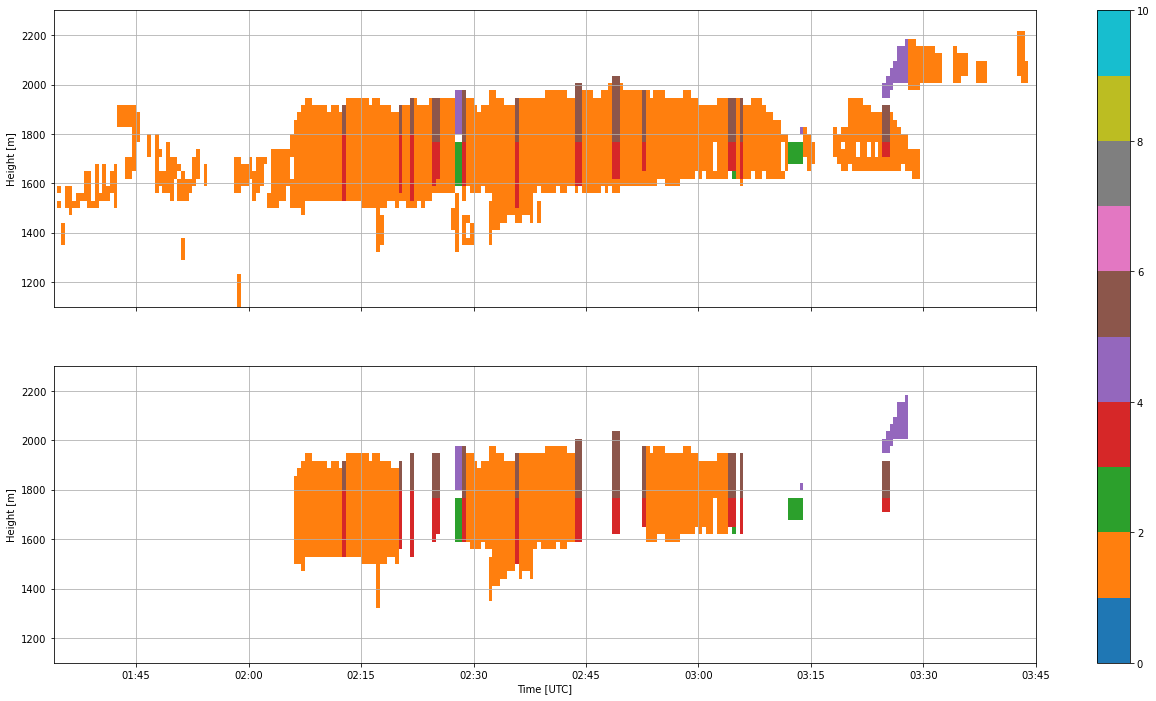

In [18]:
cloud_liquid                    = 1 # Cloud liquid droplets only
drizzle_or_rain                 = 2 # Drizzle or rain
drizzle_or_rain_liquid_droplets = 3 # Drizzle or rain coexisting with cloud liquid droplets
ice_particles                   = 4 # Ice particles
ice_with_sup_water              = 5 # Ice coexisting with supercooled liquid droplets.

test = pd.DataFrame(data=np.where( (dfnew_classification != cloud_liquid)\
                                  & (dfnew_classification != drizzle_or_rain)\
                                  & (dfnew_classification != drizzle_or_rain_liquid_droplets)\
                                  & (dfnew_classification != ice_particles)\
                                  & (dfnew_classification != ice_with_sup_water),
                                  np.NaN, 
                                  dfnew_classification),
                    index=dfnew_classification.index,
                    columns=dfnew_classification.columns)

classification_filter = Cloud_filters(test.copy(), cloud_liquid)

classification_filter.filtering_dz(100) # 100 m
classification_filter.filtering_dt(5)  # 10 min
#--------------------------------------------------------------------------------------------------
hour_s = 1
hour_e = 3
min_s  = 34
min_e  = 45
z_min  = test.columns.min() + 300   # m
z_max  = 2300 # m

fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

#cbar.set_ticks([mn,md,mx])

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

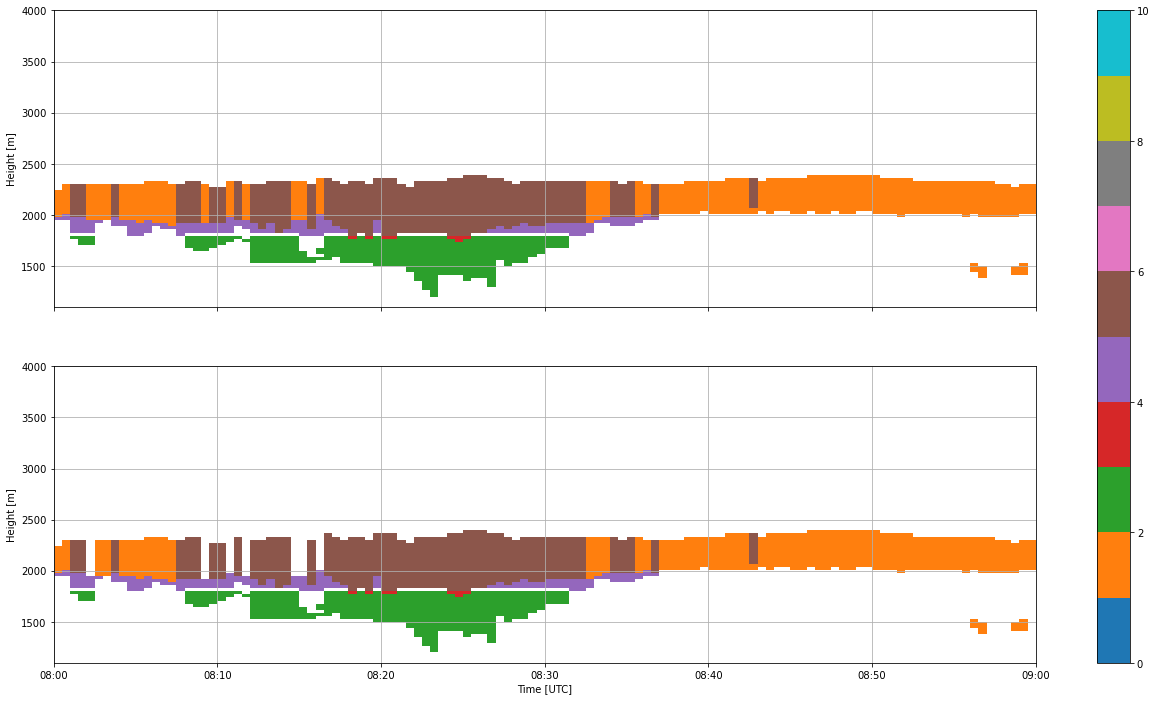

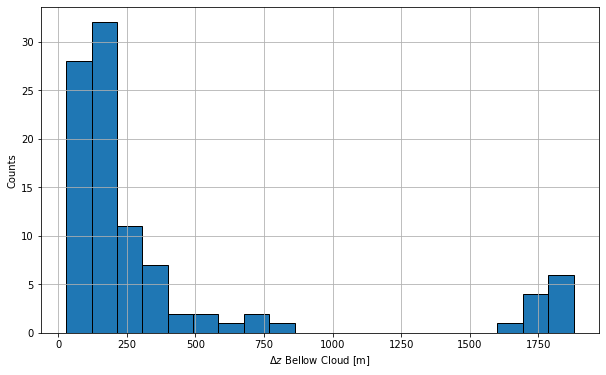

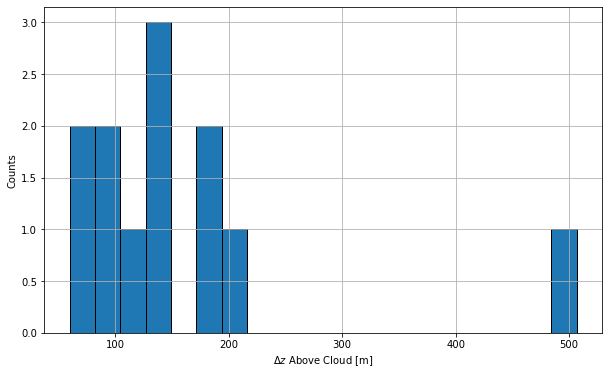

In [19]:
classification_filter = Cloud_filters(test.copy(), cloud_liquid)
dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(drizzle_or_rain)
threshold             = 500
classification_filter.filtering_specie(drizzle_or_rain, threshold, threshold)
#--------------------------------------------------------------------------------------------------
hour_s = 8
hour_e = 9
z_min  = test.columns.min() + 300   # m
z_max  = 4000 # m
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

#cbar.set_ticks([mn,md,mx])

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()


fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_bellow, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
axs.grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_above, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
axs.grid()
plt.show()

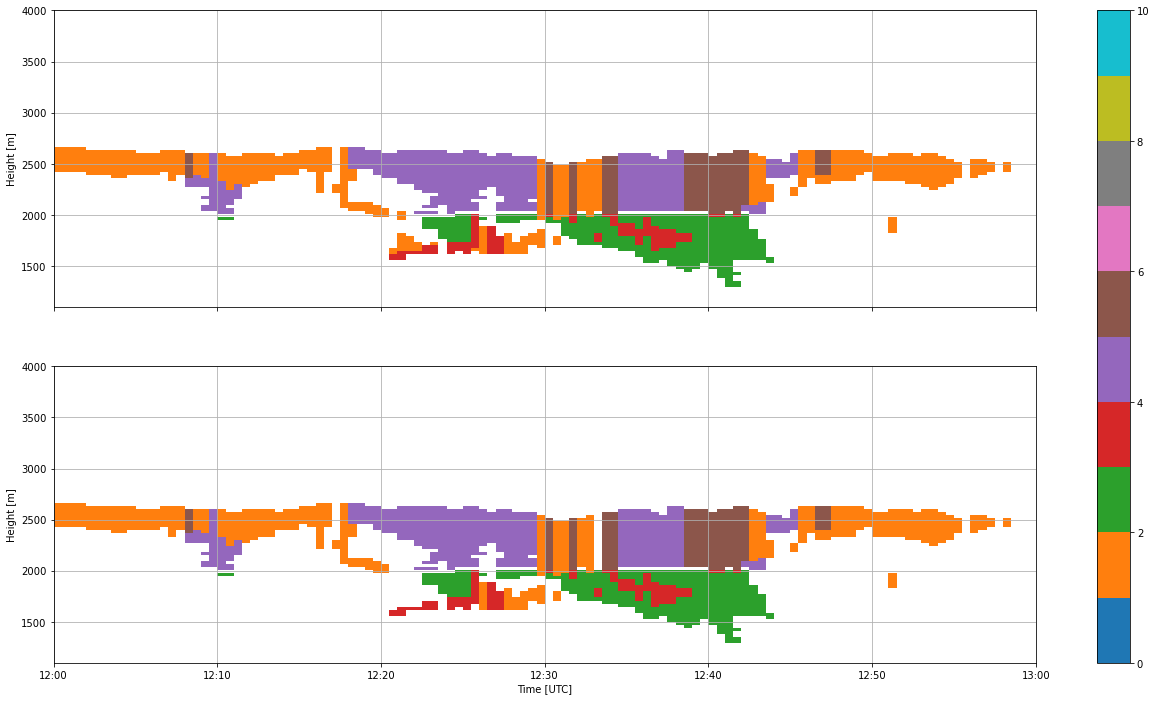

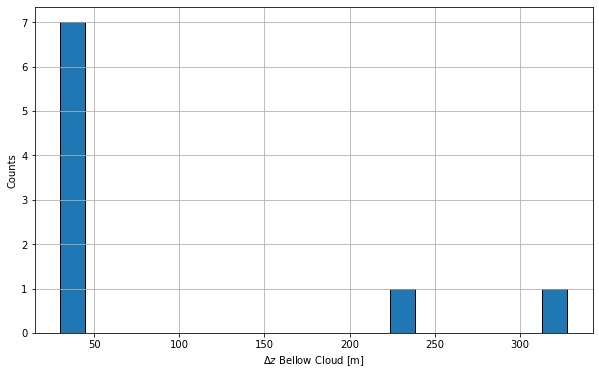

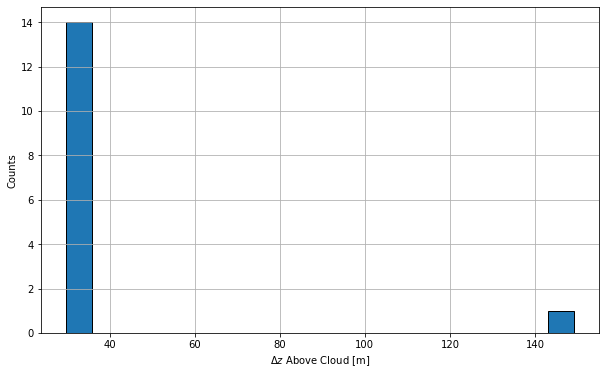

In [20]:
classification_filter = Cloud_filters(test.copy(), cloud_liquid)
dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(drizzle_or_rain_liquid_droplets)
threshold             = 500
classification_filter.filtering_specie(drizzle_or_rain_liquid_droplets, threshold, threshold)
#--------------------------------------------------------------------------------------------------
hour_s = 12
hour_e = 13
z_min  = test.columns.min() + 300   # m
z_max  = 4000 # m
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

#cbar.set_ticks([mn,md,mx])

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_bellow, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
axs.grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_above, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
axs.grid()
plt.show()

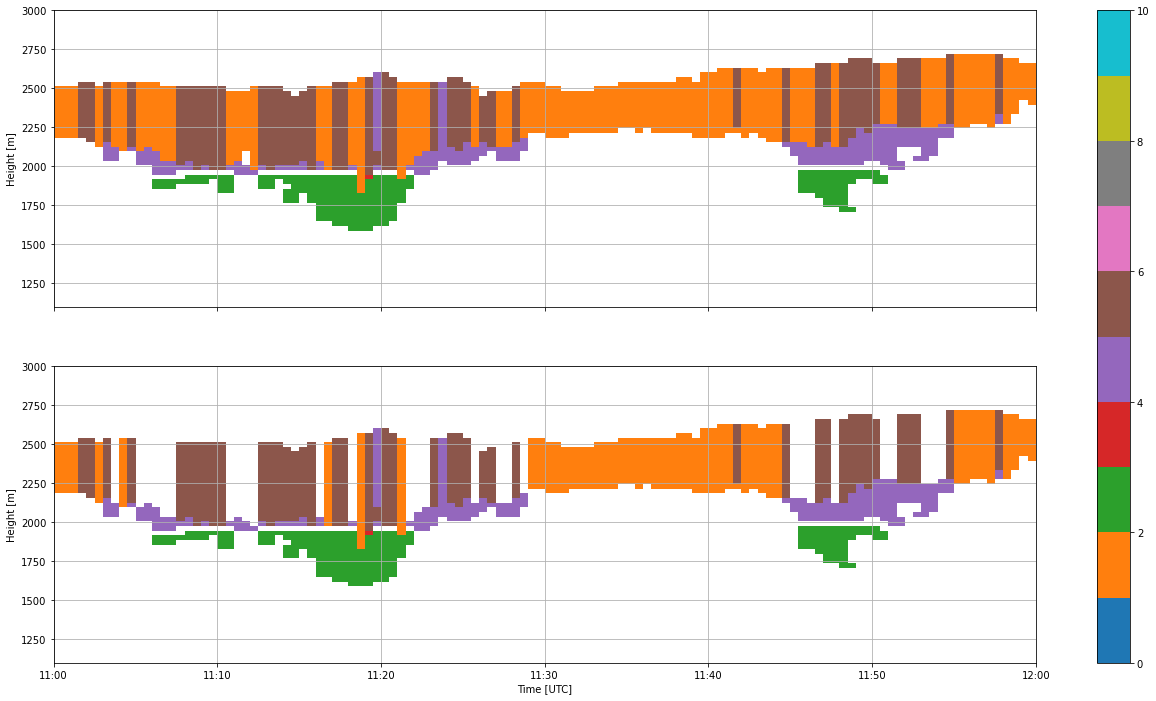

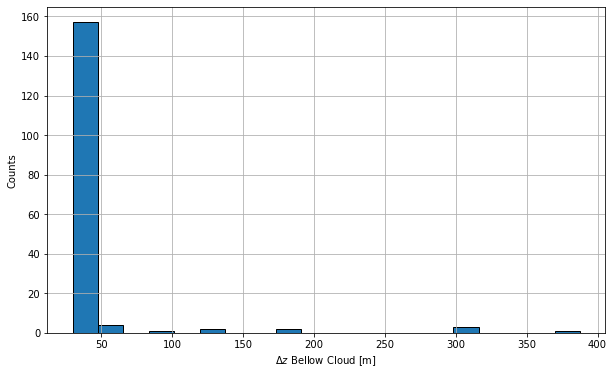

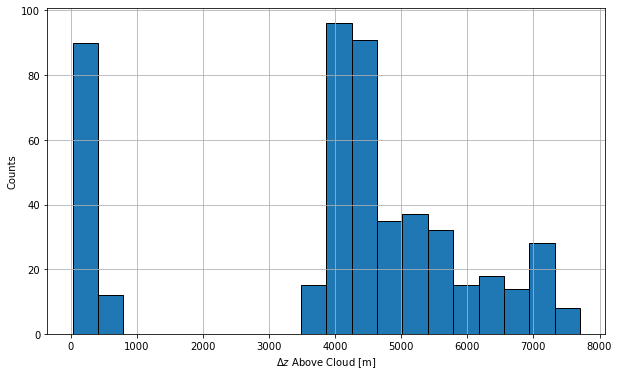

In [21]:
classification_filter = Cloud_filters(test.copy(), cloud_liquid)
dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(ice_particles)
threshold             = 500
classification_filter.filtering_specie(ice_particles, threshold, threshold)
#--------------------------------------------------------------------------------------------------
hour_s = 11
hour_e = 12
z_min  = test.columns.min() + 300   # m
z_max  = 3000 # m
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

#cbar.set_ticks([mn,md,mx])

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_bellow, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
axs.grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_above, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
axs.grid()
plt.show()

#print( np.quantile(dz_bellow, .25) )
#print( np.quantile(dz_above, .25) )

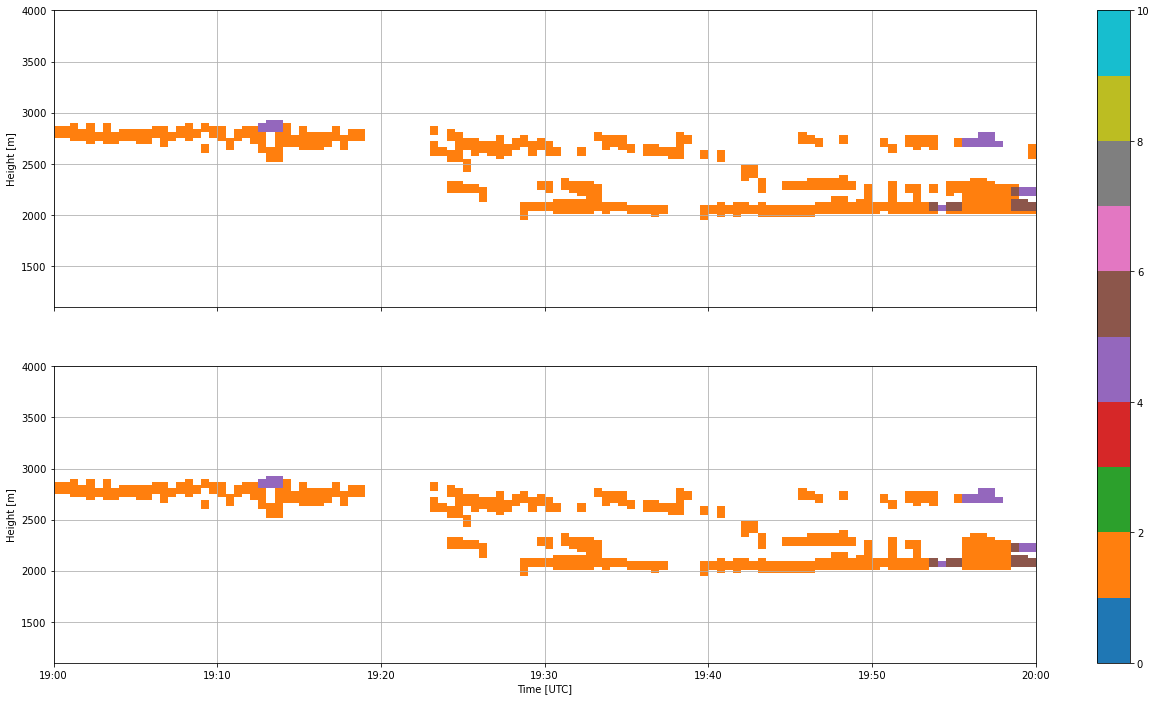

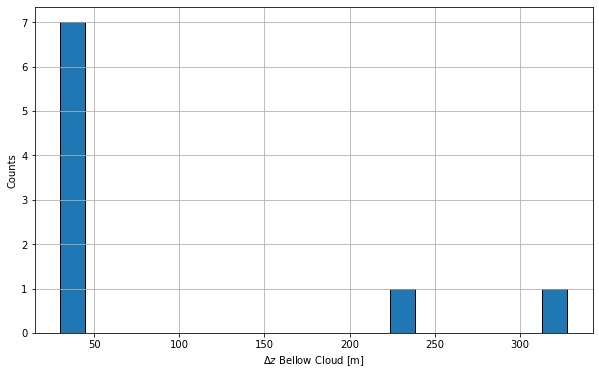

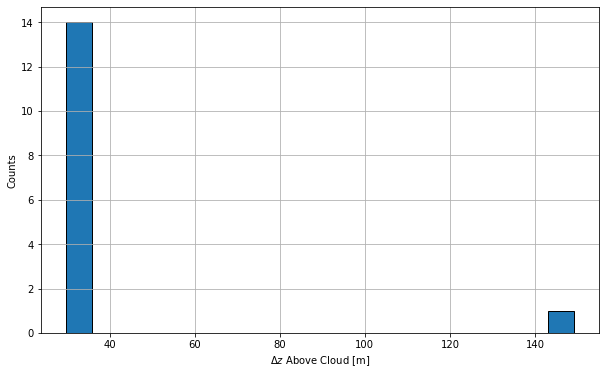

In [22]:
classification_filter = Cloud_filters(test.copy(), cloud_liquid)
dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(drizzle_or_rain_liquid_droplets)
threshold             = 500 # meters
classification_filter.filtering_specie(ice_with_sup_water, threshold, threshold)
#--------------------------------------------------------------------------------------------------
hour_s = 19
hour_e = 20
z_min  = test.columns.min() + 300   # m
z_max  = 4000 # m
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_bellow, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
axs.grid()
plt.show()

fig, axs = plt.subplots(figsize=(10, 6))

plot3 = axs.hist(dz_above, bins=20, edgecolor='black')
#plot3 = axs.boxplot(dz_bellow)
axs.set_ylabel(r'Counts')
axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
axs.grid()
plt.show()

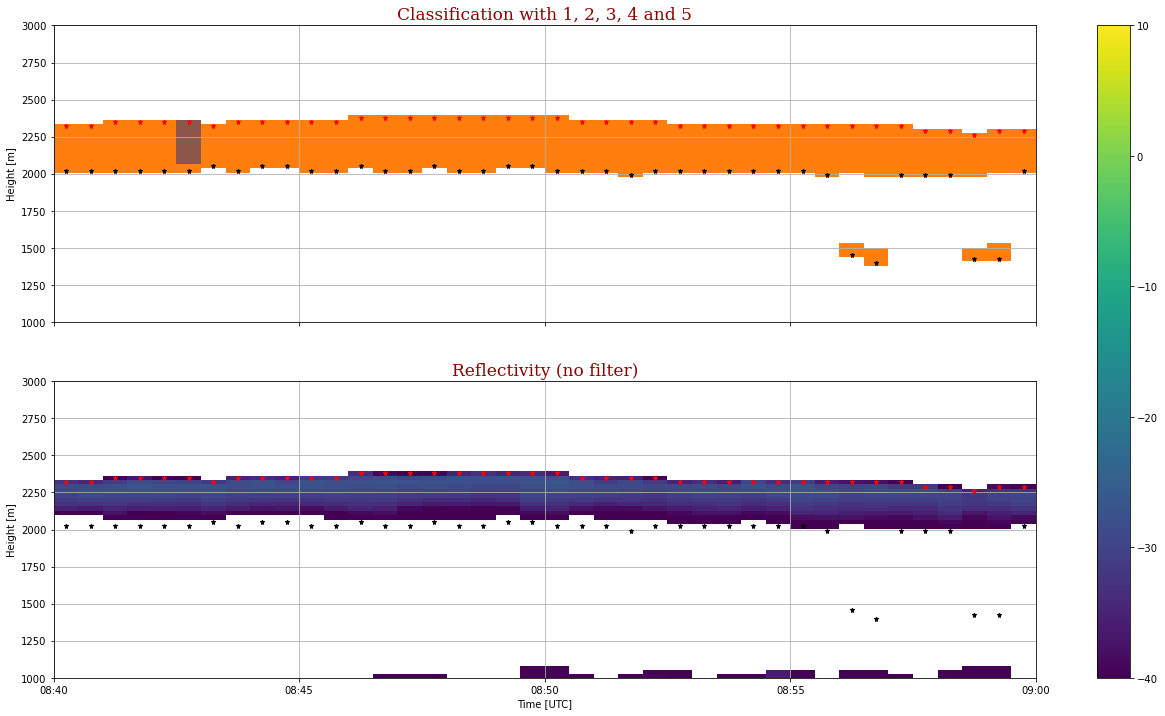

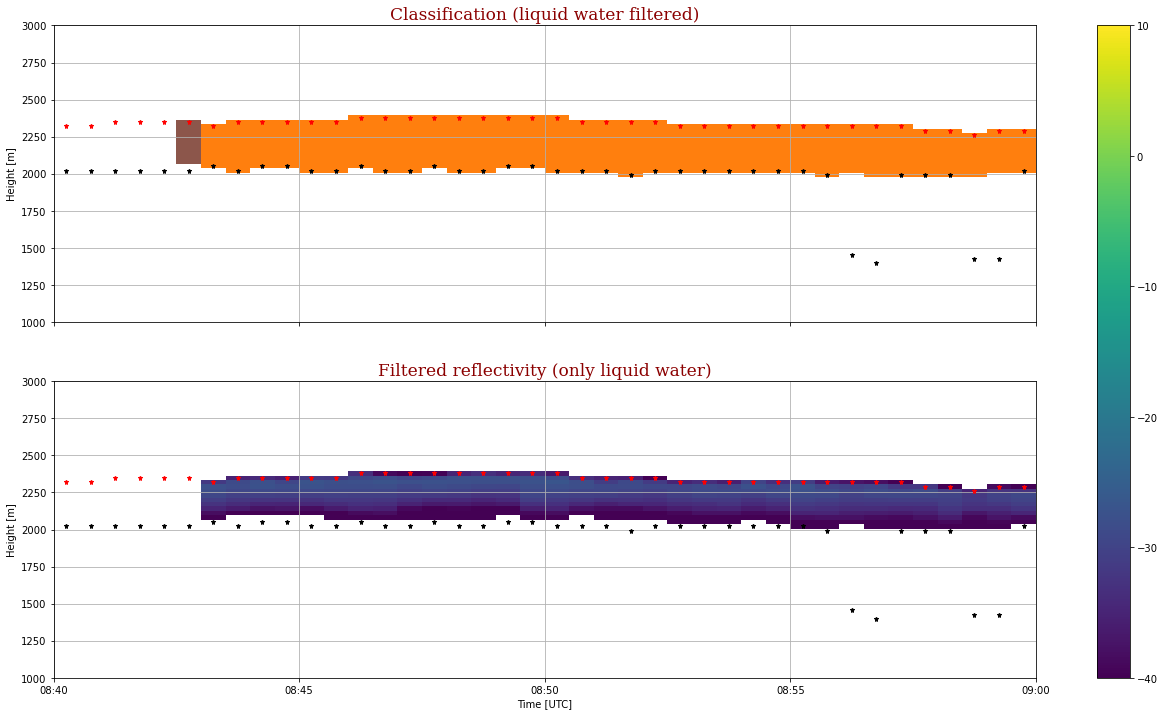

In [23]:
cloud_liquid                    = 1 # Cloud liquid droplets only
drizzle_or_rain                 = 2 # Drizzle or rain
drizzle_or_rain_liquid_droplets = 3 # Drizzle or rain coexisting with cloud liquid droplets
ice_particles                   = 4 # Ice particles
ice_with_sup_water              = 5 # Ice coexisting with supercooled liquid droplets.

test = pd.DataFrame(data=np.where( (dfnew_classification != cloud_liquid)\
                                  & (dfnew_classification != drizzle_or_rain)\
                                  & (dfnew_classification != drizzle_or_rain_liquid_droplets)\
                                  & (dfnew_classification != ice_particles)\
                                  & (dfnew_classification != ice_with_sup_water),
                                  np.NaN, 
                                  dfnew_classification),
                    index=dfnew_classification.index,
                    columns=dfnew_classification.columns)

classification_filter = Cloud_filters(test.copy(), cloud_liquid)
threshold             = 500 # meters

# The order is important. The delta time filter must be the last one

classification_filter.filtering_specie(drizzle_or_rain, threshold, threshold)
classification_filter.filtering_specie(drizzle_or_rain_liquid_droplets, threshold, threshold)
classification_filter.filtering_specie(ice_particles, threshold, threshold)
classification_filter.filtering_specie(ice_with_sup_water, threshold, threshold)
classification_filter.filtering_dz(200) # meters
classification_filter.filtering_dt(10)  # minutes

liquid_classification = classification_filter.classification.where(classification_filter.classification\
                                               == cloud_liquid, np.nan)
for time in liquid_classification.index:
    row = np.where(liquid_classification.loc[time]==cloud_liquid)[0]
    if row.size:
        layers = len(groupSequence(row))
        if layers > 1:
            print("More than 1 cloud")

ze_filtered = classification_filter.filtered_ze(dfnew_reflectivity.copy()) 
#-----------------------------------------------------------------------------------------------------------
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 17,
        }

hour_s = 8
hour_e = 9
min_s  = 40
min_e  = 0
#z_min  = test.columns.min() + 300 # m
z_min = 1000
z_max  = 3000 # m
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f0 = axs[0].pcolormesh(test.index, 
                    test.columns, 
                    np.transpose(test),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

p1 = axs[0].plot(dfnew_cb, "*", color='black', markersize=5)
p2 = axs[0].plot(dfnew_ct, "*", color='red', markersize=5)
axs[0].set_title("Classification with 1, 2, 3, 4 and 5" ,fontdict=font)
axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = axs[1].pcolormesh(dfnew_reflectivity.index, 
                    dfnew_reflectivity.columns, 
                    np.transpose(dfnew_reflectivity),
                    cmap='viridis',
                    vmin=-40,
                    vmax=10)

p3 = axs[1].plot(dfnew_cb, "*", color='black', markersize=5)
p4 = axs[1].plot(dfnew_ct, "*", color='red', markersize=5)

axs[1].set_title("Reflectivity (no filter)" ,fontdict=font)
axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

#--------------------------------------------------------------------------------------------------
fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

f3 = axs[0].pcolormesh(classification_filter.classification.index, 
                    classification_filter.classification.columns, 
                    np.transpose(classification_filter.classification),
                    cmap='tab10',
                    vmin=0,
                    vmax=10)

p5 = axs[0].plot(dfnew_cb, "*", color='black', markersize=5)
p6 = axs[0].plot(dfnew_ct, "*", color='red', markersize=5)
axs[0].set_title("Classification (liquid water filtered)" ,fontdict=font)
axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
axs[0].grid()

f3 = plt.pcolormesh(ze_filtered.index, 
                    ze_filtered.columns, 
                    np.transpose(ze_filtered),
                    cmap='viridis',
                    vmin=-40,
                    vmax=10)

p7 = axs[1].plot(dfnew_cb, "*", color='black', markersize=5)
p8 = axs[1].plot(dfnew_ct, "*", color='red', markersize=5)
axs[1].set_title("Filtered reflectivity (only liquid water)", fontdict=font)
axs[1].set_ylabel(r'Height [m]')
axs[1].set_xlabel(r'Time [UTC]')
fig.colorbar(f3, ax=axs[0:3])
#axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[1].set_ylim([z_min,z_max])
axs[1].grid()
plt.show()

In [24]:
ze_filtered = classification_filter.filtered_ze(dfnew_reflectivity.copy()) 
num_mh      = pd.DataFrame(index=ze_filtered.index.array,
                           data=np.zeros(ze_filtered.shape[0])) # homogeneos mixing 
ref_mh      = pd.DataFrame(data=np.zeros( (ze_filtered.shape[0], ze_filtered.shape[1])), 
                           index=ze_filtered.index.array, 
                           columns=categorize["height"][:])  # homogeneos mixing

for ind in ze_filtered.index:
    #i_cbase = np.argmax(categorize["height"][:] == dfnew_cb.loc[ind][0]) 
    #i_ctop  = np.argmax(categorize["height"][:] == dfnew_ct.loc[ind][0]) 
    z_profile = ze_filtered.loc[ind]
    #print( np.diff(z_profile))
    ze                        = 10**(z_profile[z_profile.notnull()]/10) # Remove NaNs and convert Z from dBz to mm^6 m^-3
    
    cloud_model               = HMmodel( dfnew_lwp.loc[ind][0],
                                         ze.index.array,
                                         ze)
    num_mh.loc[ind]           = cloud_model.get_num()
    ref_mh.loc[ind, ze.index] = cloud_model.get_re()
    
num_mh.replace([np.inf, -np.inf], np.nan, inplace=True)
ref_mh.replace(0, np.nan, inplace=True)

/tmp/ipykernel_1568564/580430287.py:73: RuntimeWarning: divide by zero encountered in double_scalars
  return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2


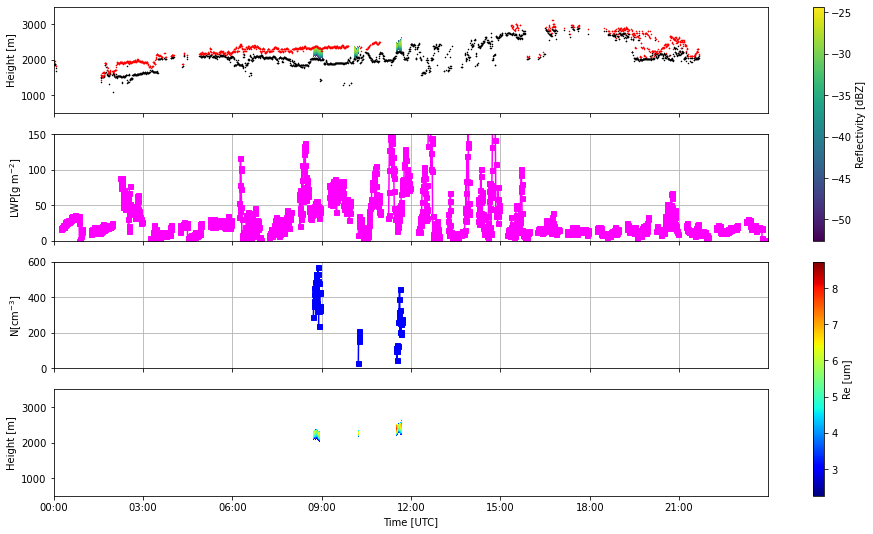

In [25]:
hour_s = 0
hour_e = 23
min_s  = 0
min_e  = 59
z_min  = 500  # m
z_max  = 3500 # m
fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

f1 = axs[0].pcolormesh(ze_filtered.index, 
                        ze_filtered.columns, 
                        np.transpose(ze_filtered),
                        cmap='viridis')
f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=1)
f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=1)

axs[0].set_ylabel(r'Height [m]')
fig.colorbar(f1, ax=axs[0:2],  label='Reflectivity [dBZ]')
axs[0].set_ylim([z_min,z_max])

f4 = axs[1].plot(dfnew_lwp, "s-", color='magenta', markersize=5, markerfacecolor='magenta')

axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
axs[1].set_ylim([0,150])
axs[1].grid()

f5 = axs[2].plot(num_mh, "-s", color='blue', markersize=5)

axs[2].set_ylabel(r'N[cm$^{-3}$]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].set_ylim([0,600])
axs[2].grid()

f6 = axs[3].pcolormesh(ref_mh.index, 
                    ref_mh.columns, 
                    np.transpose(ref_mh),
                    cmap='jet')

axs[3].set_ylabel(r'Height [m]')
axs[3].set_xlabel(r'Time [UTC]')
fig.colorbar(f6, ax=axs[2:4], label='Re [um]')
#axs.set_ylim([1000,2300])
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3].set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[3].set_ylim([z_min,z_max])
plt.show()

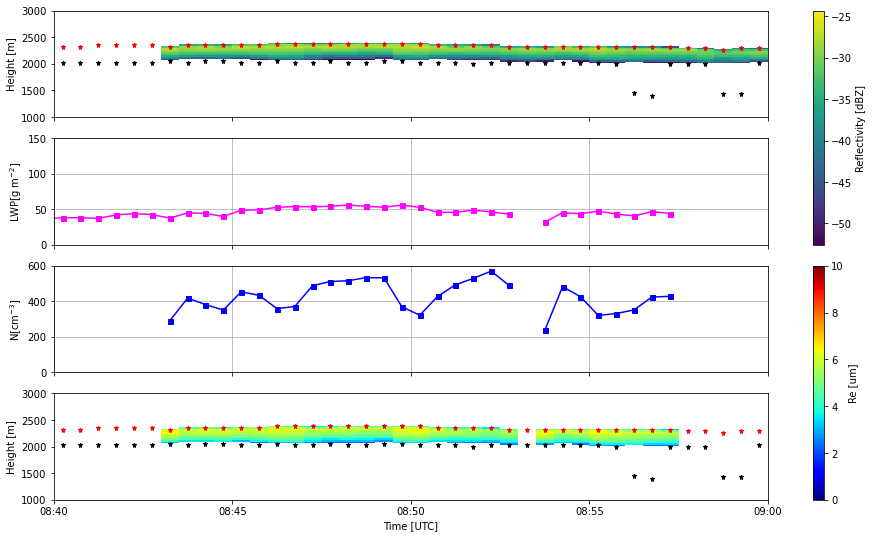

In [26]:
hour_s = 8
hour_e = 9
min_s = 40
min_e = 0
z_min  = 1000  # m
z_max  = 3000 # m
fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

f1 = axs[0].pcolormesh(ze_filtered.index, 
                        ze_filtered.columns, 
                        np.transpose(ze_filtered),
                        cmap='viridis')
p1 = axs[0].plot(dfnew_cb, "*", color='black', markersize=5)
p2 = axs[0].plot(dfnew_ct, "*", color='red', markersize=5)

axs[0].set_ylabel(r'Height [m]')
fig.colorbar(f1, ax=axs[0:2],  label='Reflectivity [dBZ]')
axs[0].set_ylim([z_min,z_max])

f4 = axs[1].plot(dfnew_lwp, "s-", color='magenta', markersize=5, markerfacecolor='magenta')

axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
axs[1].set_ylim([0,150])
axs[1].grid()

f5 = axs[2].plot(num_mh, "-s", color='blue', markersize=5)

axs[2].set_ylabel(r'N[cm$^{-3}$]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].set_ylim([0,600])
axs[2].grid()

f6 = axs[3].pcolormesh(ref_mh.index, 
                    ref_mh.columns, 
                    np.transpose(ref_mh),
                    cmap='jet',
                    vmin=0,
                    vmax=10)

p3 = axs[3].plot(dfnew_cb, "*", color='black', markersize=5)
p4 = axs[3].plot(dfnew_ct, "*", color='red', markersize=5)

axs[3].set_ylabel(r'Height [m]')
axs[3].set_xlabel(r'Time [UTC]')
fig.colorbar(f6, ax=axs[2:4], label='Re [um]')
#axs.set_ylim([1000,2300])
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3].set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[3].set_ylim([z_min,z_max])
plt.show()

In [27]:
dfnew_lwp

,0
2021-04-29 00:00:15.000001,NaN
2021-04-29 00:00:45.000001,NaN
2021-04-29 00:01:15.000002,NaN
2021-04-29 00:01:45.000000,NaN
2021-04-29 00:02:15.000005,NaN
...,...
2021-04-29 23:57:44.998627,NaN
2021-04-29 23:58:14.998169,NaN
2021-04-29 23:58:44.997711,NaN
2021-04-29 23:59:14.997253,NaN


In [28]:
cloudnet_der['der']

<class 'netCDF4._netCDF4.Variable'>
float32 der(time, height)
    _FillValue: 9.96921e+36
    units: m
    long_name: Droplet effective radius
    comment: This variable was calculated for the profiles where the categorization data has
diagnosed that liquid water is present the cloud droplet effective radius is calculated
after Frisch et al (2002), relating Z with def by assuming a lognormal size distribution
its width and the number concentration of the cloud droplets.
    ancillary_variables: der_error
unlimited dimensions: 
current shape = (2880, 380)
filling on

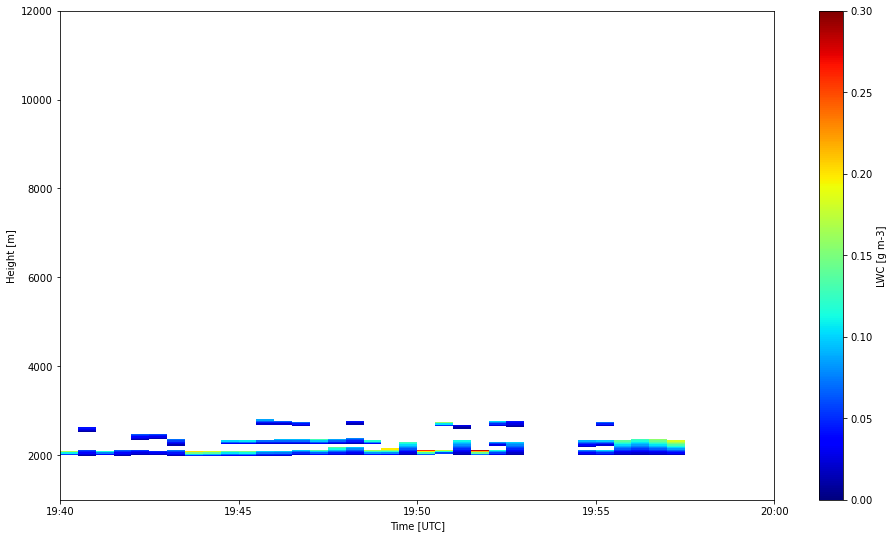

In [29]:
fig, axs = plt.subplots(figsize=(16, 9))
hour_s = 19
hour_e = 20
min_s  = 40
min_e  = 0
z_min  = 1000  # m
z_max  = 12000 # m

dfnew_cloudnet_lwc.replace(0, np.nan, inplace=True)
der_filtered = classification_filter.filtered_ze(dfnew_cloudnet_der.copy())
der_filtered.replace(np.nanmax(dfnew_cloudnet_der), np.nan, inplace=True) # verificar

f1 = axs.pcolormesh(dfnew_cloudnet_lwc.index, 
                        dfnew_cloudnet_lwc.columns, 
                        np.transpose(dfnew_cloudnet_lwc),
                        cmap='jet',
                   vmin=0,
                   vmax=.3)
#f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=1)
#f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=1)

axs.set_ylabel(r'Height [m]')
axs.set_xlabel(r'Time [UTC]')
fig.colorbar(f1, label='LWC [g m-3]')
axs.set_ylim([z_min,z_max])
axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs.set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
plt.show()

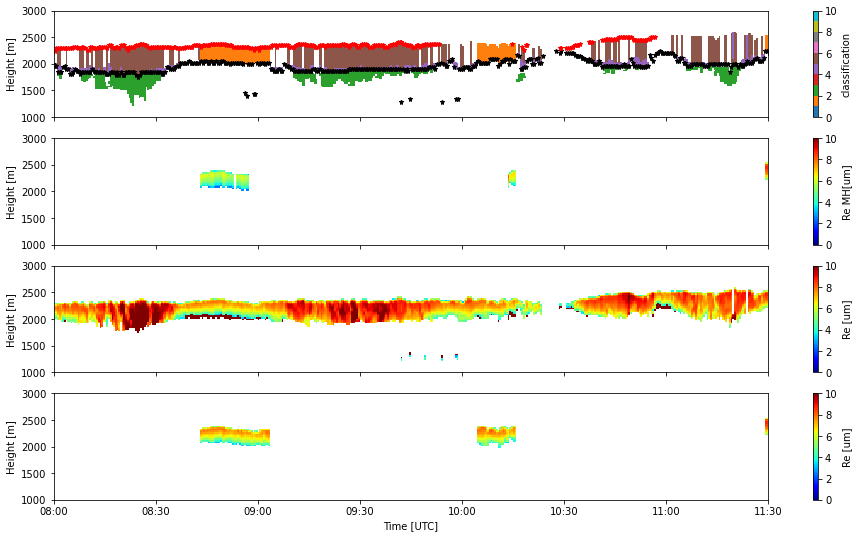

In [30]:
hour_s = 8
hour_e = 11
min_s  = 0
min_e  = 30
z_min  = 1000  # m
z_max  = 3000 # m
fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

f1 = axs[0].pcolormesh(classification_filter.classification.index, 
                        classification_filter.classification.columns, 
                        np.transpose(classification_filter.classification),
                        cmap='tab10',
                      vmin=0,
                      vmax=10)

p1 = axs[0].plot(dfnew_cb, "*", color='black', markersize=5)
p2 = axs[0].plot(dfnew_ct, "*", color='red', markersize=5)

axs[0].set_ylabel(r'Height [m]')
axs[0].set_ylim([z_min,z_max])
fig.colorbar(f1, ax=axs[0:1], label='classification')

f2 = axs[1].pcolormesh(ref_mh.index, 
                       ref_mh.columns, 
                       np.transpose(ref_mh),
                        cmap='jet', 
                      vmin=0,
                      vmax=10)

axs[1].set_ylabel(r'Height [m]')
axs[1].set_ylim([z_min,z_max])

fig.colorbar(f2, ax=axs[1:2], label='Re MH[um]')

f3 = axs[2].pcolormesh(dfnew_cloudnet_der.index, 
                       dfnew_cloudnet_der.columns, 
                       np.transpose(dfnew_cloudnet_der),
                        cmap='jet', 
                      vmin=0,
                      vmax=10)

axs[2].set_ylabel(r'Height [m]')
axs[2].set_ylim([z_min,z_max])
fig.colorbar(f3, ax=axs[2:3], label='Re [um]')


f4 = axs[3].pcolormesh(der_filtered.index, 
                       der_filtered.columns, 
                       np.transpose(der_filtered),
                        cmap='jet', 
                      vmin=0,
                      vmax=10)

axs[3].set_ylabel(r'Height [m]')
axs[3].set_xlabel(r'Time [UTC]')
fig.colorbar(f4, ax=axs[3:4], label='Re [um]')


#axs.set_ylim([1000,2300])
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3].set_xlim([ref_mh.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                 ref_mh.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
axs[3].set_ylim([z_min,z_max])
#axs[2].set_xlim([hour_s,hour_e])
plt.show()

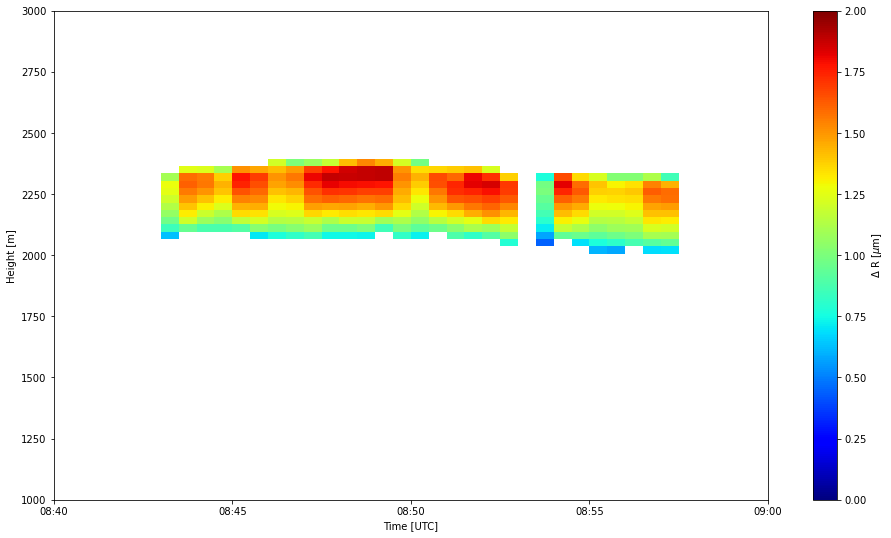

In [31]:

hour_s = 8
hour_e = 9
min_s = 40
min_e = 0
z_min  = 1000  # m
z_max  = 3000 # m

dfnew_cloudnet_lwc.replace(0, np.nan, inplace=True)
der_filtered = classification_filter.filtered_ze(dfnew_cloudnet_der.copy())
der_filtered.replace(np.nanmax(dfnew_cloudnet_der), np.nan, inplace=True) # verificar

fig, axs = plt.subplots(figsize=(16, 9))
f1 = axs.pcolormesh(der_filtered.index, 
                        der_filtered.columns, 
                        np.transpose(der_filtered - ref_mh),
                        cmap='jet',
                   vmin=-0.0,
                   vmax=2.0)
#f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=1)
#f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=1)

axs.set_ylabel(r'Height [m]')
axs.set_xlabel(r'Time [UTC]')
fig.colorbar(f1, label='$\Delta$ R [$\mu$m]')
axs.set_ylim([z_min,z_max])
axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs.set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
             ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
plt.show()

In [32]:
print(categorize['Z'][1,:])
print(categorize['Z_error'][1,:])

[-- -60.97214889526367 -55.39155197143555 -- -- -- -- -46.95067596435547
 -40.84724807739258 -- -- -40.17192077636719 -46.94380187988281 -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -48.36289978027344 -45.813392639160156 -40.631038665771484 -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

In [33]:
#null_cols = der_filtered.columns[der_filtered.isnull().all()]
#x = der_filtered.drop(null_cols, axis = 1, inplace = True)
#print(x)

In [34]:
#print(categorize['model_time'][:])
#print(categorize['model_height'][:])
#print(categorize['temperature'][:])
model_ecmwf = pd.DataFrame(data=categorize['temperature'][:],
                                        index=categorize['model_time'][:],
                                        columns=categorize['model_height'][:])
model_ecmwf

,689.891846,710.607910,733.218994,757.784241,784.469543,813.495361,845.070557,879.423279,916.798279,957.460999,...,54896.019531,56876.929688,58857.535156,61095.476562,63066.156250,65756.789062,67649.218750,70261.007812,72089.312500,78211.312500
0.0,282.660675,282.959595,282.877808,282.667419,282.406281,282.125214,281.794098,281.443146,281.062134,280.650818,...,255.310349,247.511749,242.870224,237.506287,229.941254,227.645798,225.678040,222.920120,218.139526,206.569794
1.0,282.360840,282.700256,282.738495,282.606537,282.365906,282.073822,281.732758,281.371582,280.969604,280.537262,...,253.635284,246.398071,242.442825,237.148087,230.245163,227.756195,225.530380,222.546936,217.879959,206.189636
2.0,282.200775,282.469879,282.458252,282.325897,282.083801,281.781250,281.430450,281.079102,280.696198,280.265015,...,253.436371,246.515579,242.357635,237.216553,230.772217,228.471024,226.091034,223.226440,218.358490,206.848419
3.0,281.900665,282.088715,281.987488,281.834747,281.592529,281.310638,280.988495,280.637238,280.296967,279.963715,...,253.025589,246.247482,242.435089,237.900665,232.152908,229.788956,226.903137,223.629745,217.901611,205.320572
4.0,281.750885,281.978851,281.856384,281.654114,281.401611,281.110077,280.798096,280.466400,280.135437,279.813171,...,252.197586,246.279800,243.515793,238.963486,233.354385,230.129196,226.566376,222.670181,216.747864,203.538116
5.0,281.701691,282.119385,282.055847,281.823700,281.551453,281.250275,280.938721,280.617126,280.294952,279.953705,...,252.297592,246.935562,244.465103,239.101486,233.016510,228.757156,225.064758,221.188065,216.076355,203.089676
6.0,281.931122,282.228394,282.106323,281.893860,281.621887,281.329498,280.988190,280.647308,280.325470,279.972839,...,252.047501,247.373871,244.131226,238.531403,231.788574,227.785583,224.385330,221.073730,216.005798,203.164764
7.0,282.529297,282.268311,282.036102,281.784668,281.533966,281.281128,280.988892,280.665436,280.274506,279.883270,...,252.664246,247.484100,244.165329,238.515594,231.785126,227.885178,224.576050,221.214050,215.926483,202.442108
8.0,283.199463,282.818848,282.527039,282.246735,281.964874,281.653809,281.331696,280.969757,280.568512,280.156860,...,253.604996,247.797119,244.285110,238.472977,231.733154,227.850418,224.719986,221.037338,215.316025,200.656143
9.0,283.979919,283.489777,283.148315,282.848450,282.547241,282.236542,281.905365,281.554352,281.173462,280.773010,...,254.399963,248.238602,244.675064,239.319717,232.452774,228.552399,224.979324,221.021896,214.788361,199.757950


In [35]:
#df_der     = ref_mh.copy()
df_der     = der_filtered.copy()
df_lwc_new = dfnew_cloudnet_lwc.copy()
df_ze      = ze_filtered.copy()

df_der.dropna(axis = 0, how = 'all', inplace = True)
df_lwc_new.dropna(axis = 0, how = 'all', inplace = True)
df_ze.dropna(axis = 0, how = 'all', inplace = True)

pr = 0
ze_data  = df_ze.iloc[pr,:].dropna()
derdata  = df_der.iloc[pr,:].dropna()
lwcdata  = df_lwc_new.loc[derdata.name,:].dropna()

#print(ydata)
#print(model_ecmwf.loc[8.0,:])
tempdata =model_ecmwf.loc[derdata.name.hour,:].dropna()
#print(tempdata.index)

In [36]:
f0 = interpolate.interp1d(ze_data.index, ze_data)
f1 = interpolate.interp1d(derdata.index, derdata)
f2 = interpolate.interp1d(tempdata.index, tempdata)
f3 = interpolate.interp1d(lwcdata.index, lwcdata)

zcloud  = derdata.index
deltah  = np.unique( np.diff( zcloud ) )[0]
#deltah  = 30.0
znew    = np.arange( zcloud[0], zcloud[-1]+1, deltah) # simulador de radar só tem um intervalo 
zenew   = f0(znew)
dernew  = f1(znew)
tempnew = f2(znew)-273.15
lwcnew  = f3(znew)

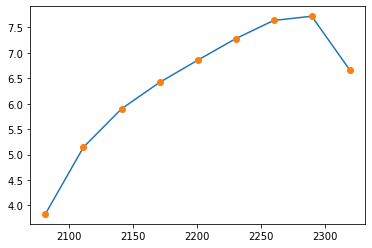

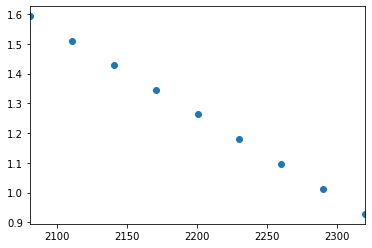

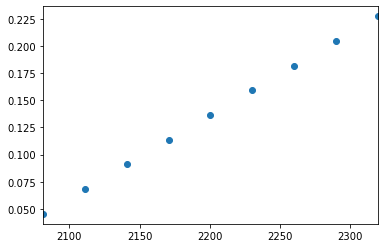

In [37]:
plt.figure()
plt.plot(derdata)
plt.plot(znew, dernew, 'o')
plt.show()

plt.figure()
#plt.plot(tempdata)
plt.plot(znew, tempnew, 'o')
plt.xlim([znew[0],znew[-1]])
plt.show()

plt.figure()
#plt.plot(tempdata)
plt.plot(znew, lwcnew, 'o')
plt.xlim([znew[0],znew[-1]])
plt.show()

In [38]:
from scipy.optimize import curve_fit

In [39]:
# range_gates     = 400
# ncloud          = znew.size
# instrument_info = np.array([3.19, 0.0, 0.0, categorize['altitude'][:]], float)
# output_info     = np.array([range_gates, deltah, categorize['height'][0], -1], float)
# #instrument_info = np.array([3.19, 0.0, 0.0,0.0], float)
# #output_info     = np.array([range_gates, deltah, 0.0, -1], float)

# height          = znew
# thickness       = np.array(ncloud*[29.811], float)
# reff            = dernew
# dist            = np.array(ncloud*["gamma"], str)
# distparam       = np.array(ncloud*[8.7], float)
# max_rad_factor  = np.array(ncloud*[7.], float)
# temp            = tempnew
# phase           = np.array(ncloud*["water"], str)
# lwc             = lwcnew # g/m^3

# PATH_RADAR_INP = "../ssradar_inp/"
# PATH_RADAR_OUT = "../ssradar_out/"
# model_radar = Radar(PATH_RADAR_INP + "test.inp",
#                      PATH_RADAR_OUT+ "test.out",
#                      instrument_info,
#                      output_info, 
#                      height, 
#                      thickness, 
#                      reff, 
#                      dist, 
#                      distparam, 
#                      max_rad_factor, 
#                      temp,
#                      phase, 
#                      lwc)

# model_radar.write_input()
# model_radar.run()
# data = model_radar.get_output()

In [40]:
# # nu = 12
# # ze_simulated = model_radar.simulated_signal(znew, nu)
# fig, axs = plt.subplots(figsize=(5, 8))
# #fig.suptitle('Sharing both axes')
# p1 = plt.plot(zenew, znew, color='blue', marker='o', label="radar data")
# p2 = plt.plot(data[:,3], data[:,2], color='red', marker='*', label="simulated")
# # p2 = plt.plot(ze_simulated, model_radar.result[:,2], color='black', label="nu=%.1f"%(nu))

# axs.set_ylabel(r'z [m]', fontsize = 12.0)
# axs.set_xlabel(r'Reflectivity [dBZ]', fontsize = 12.0)
# axs.set_ylim([1500, 2500])
# axs.set_xlim([-50, -20])
# axs.legend()
# plt.show()

# #-----------------------------------------------------------------------------------------------
# # popt, pcov = curve_fit(model_radar.simulated_signal, znew, zenew, p0=5)

# # nu = popt
# # ze_simulated = model_radar.simulated_signal(znew, nu[0])
# # fig, axs = plt.subplots(figsize=(5, 8))
# # #fig.suptitle('Sharing both axes')
# # p1 = plt.plot(zenew, znew, color='blue', marker='o', label="radar data")
# # p2 = plt.plot(data[:,3], data[:,2], color='red', marker='*', label="simulated")
# # p2 = plt.plot(ze_simulated, model_radar.result[:,2], color='black', label="nu=%.1f"%(nu))


# # axs.set_ylabel(r'z [m]', fontsize = 12.0)
# # axs.set_xlabel(r'Reflectivity [dBZ]', fontsize = 12.0)
# # axs.set_ylim([1500, 2500])
# # axs.set_xlim([-50, -20])
# # axs.legend()
# # plt.show()

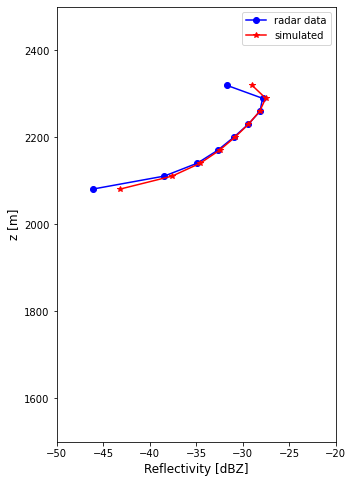

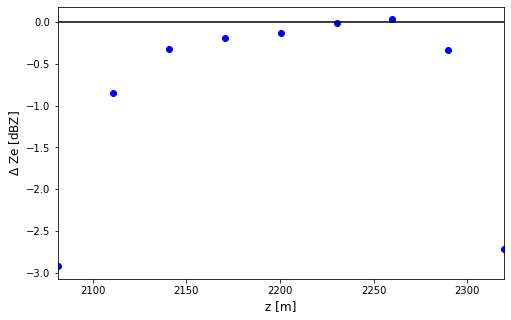

In [41]:
range_gates     = znew.size
ncloud          = znew.size
instrument_info = np.array([3.19, 0.0, 0.0, categorize['altitude'][:]], float)
output_info     = np.array([range_gates, deltah, znew[0], -1], float)
#instrument_info = np.array([3.19, 0.0, 0.0,0.0], float)
#output_info     = np.array([range_gates, deltah, 0.0, -1], float)

height          = znew
thickness       = np.array(ncloud*[29.811], float)
reff            = dernew
dist            = np.array(ncloud*["gamma"], str)
distparam       = np.array(ncloud*[25.], float)
max_rad_factor  = np.array(ncloud*[7.], float)
temp            = tempnew
phase           = np.array(ncloud*["water"], str)
lwc             = lwcnew # g/m^3

PATH_RADAR_INP = "../ssradar_inp/"
PATH_RADAR_OUT = "../ssradar_out/"
model_radar = Radar(PATH_RADAR_INP + "test.inp",
                     PATH_RADAR_OUT+ "test.out",
                     instrument_info,
                     output_info, 
                     height, 
                     thickness, 
                     reff, 
                     dist, 
                     distparam, 
                     max_rad_factor, 
                     temp,
                     phase, 
                     lwc)

model_radar.write_input()
model_radar.run()
data = model_radar.get_output()

fig, axs = plt.subplots(figsize=(5, 8))
p1 = plt.plot(zenew, znew, color='blue', marker='o', label="radar data")
p2 = plt.plot(data[:,3], data[:,2], color='red', marker='*', label="simulated")


axs.set_ylabel(r'z [m]', fontsize = 12.0)
axs.set_xlabel(r'Reflectivity [dBZ]', fontsize = 12.0)
axs.set_ylim([1500, 2500])
axs.set_xlim([-50, -20])
axs.legend()
plt.show()

fig, axs = plt.subplots(figsize=(8, 5))
p1 = plt.scatter(znew, zenew-data[:,3],color='blue', marker='o')
p1 = plt.plot(znew, np.zeros(znew.size),color='black')


axs.set_xlabel(r'z [m]', fontsize = 12.0)
axs.set_ylabel(r'$\Delta$ Ze [dBZ]', fontsize = 12.0)
#axs.set_ylim([1500, 2500])
axs.set_xlim([znew[0], znew[-1]])
#axs.legend()
plt.show()

In [42]:
range_gates     = znew.size
ncloud          = znew.size
instrument_info = np.array([3.19, 0.0, 0.0, categorize['altitude'][:]], float)
output_info     = np.array([range_gates, deltah, znew[0], -1], float)
#instrument_info = np.array([3.19, 0.0, 0.0,0.0], float)
#output_info     = np.array([range_gates, deltah, 0.0, -1], float)

height          = znew
thickness       = np.array(ncloud*[29.811], float)
reff            = dernew
dist            = np.array(ncloud*["gamma"], str)
distparam       = np.array(ncloud*[12.], float)
max_rad_factor  = np.array(ncloud*[7.], float)
temp            = tempnew*10
phase           = np.array(ncloud*["water"], str)
lwc             = lwcnew # g/m^3

PATH_RADAR_INP  = "../ssradar_inp/"
PATH_RADAR_OUT  = "../ssradar_out/"
model_radar  = Radar(PATH_RADAR_INP + "test.inp",
                     PATH_RADAR_OUT+ "test.out",
                     instrument_info,
                     output_info, 
                     height, 
                     thickness, 
                     reff, 
                     dist, 
                     distparam, 
                     max_rad_factor, 
                     temp,
                     phase, 
                     lwc)
#---------------------------------------------------------------------------------------------------------
nz           = znew.size
re_i, re_f   = 1, 15 # [microns]

dre          = .1 
range_radius = np.arange(re_i, re_f, dre)
nre          = range_radius.size
# simulated_signal_change_re
xv, yv       = np.meshgrid(range_radius, znew)
frequency    = np.zeros( (nz, nre) )
result_re    = []
result_fe    = []
re_mean      = np.zeros(nz)
#---------------------------------------------------------------------------------------------------------
for i in range(nz):
    print("Level = %d/%d"%(i+1,nz))
    re_move = re_i*np.ones(nz) # vertical effective radius
    res_re  = []
    res_fe  = []
    for j in range(nre):
        re_move[i]     = range_radius[j] 
        simulated      = model_radar.simulated_signal_change_re(re_move)
        frequency[i,j] = 1 - zenew[i]/simulated[i,3]
        
        if abs(frequency[i,j]) <= .1:
            res_re.append(range_radius[j])
            res_fe.append(frequency[i,j])
        
    result_re.append( res_re )
    result_fe.append( res_fe )
    re_mean[i] = np.median(res_re)
    
reff_res = np.zeros(nz)
for i in range(nz):
    index_res   = result_fe[i].index(min(result_fe[i], key=abs))
    reff_res[i] = result_re[i][index_res]

Level = 1/9
Level = 2/9
Level = 3/9
Level = 4/9
Level = 5/9
Level = 6/9
Level = 7/9
Level = 8/9
Level = 9/9


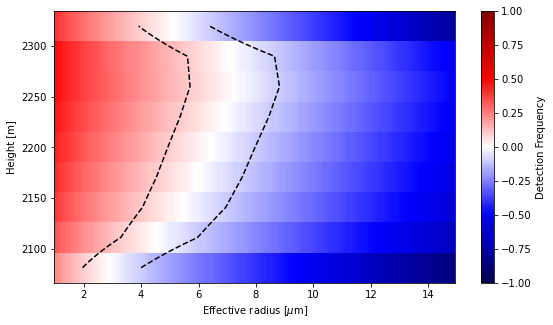

In [43]:
fig, axs = plt.subplots(figsize=(9,5))
f0 = axs.pcolormesh(range_radius, 
                    znew, 
                    frequency,
                    cmap='seismic', 
                    vmin=-1,
                    vmax=1)

contour = plt.contour(range_radius, znew, frequency, colors='black', linestyles='dashed', levels = [-.1, .1,])
axs.set_ylabel(r'Height [m]')
axs.set_xlabel(r'Effective radius [$\mu$m]')
#axs.set_ylim([z_min,z_max])
fig.colorbar(f0, label='Detection Frequency')
plt.show()

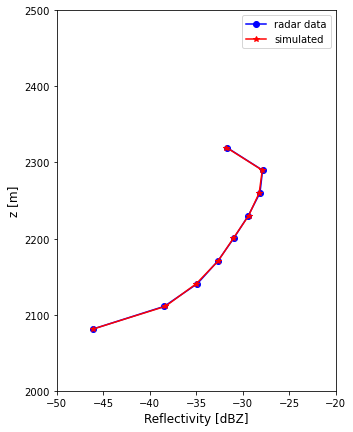

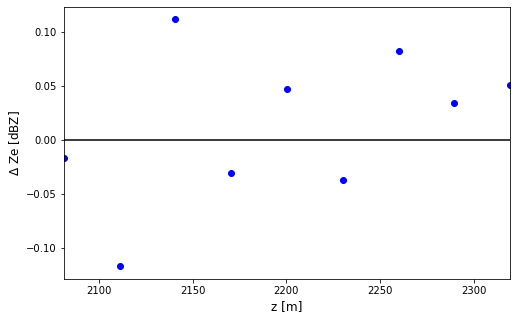

In [47]:
fit_model= model_radar.simulated_signal_change_re(reff_res)
# fit_model= model_radar.simulated_signal_change_re(re_mean)
fig, axs = plt.subplots(figsize=(5, 7))
p1 = plt.plot(zenew, znew, color='blue', marker='o', label="radar data")
p2 = plt.plot(fit_model[:,3], fit_model[:,2], color='red', marker='*', label="simulated")
#p3 = plt.plot(re_mean, znew, '--k', label="simulated")


axs.set_ylabel(r'z [m]', fontsize = 12.0)
axs.set_xlabel(r'Reflectivity [dBZ]', fontsize = 12.0)
axs.set_ylim([2000, 2500])
axs.set_xlim([-50, -20])
axs.legend()
plt.show()

fig, axs = plt.subplots(figsize=(8, 5))
p1 = plt.scatter(znew, zenew-fit_model[:,3],color='blue', marker='o')
p1 = plt.plot(znew, np.zeros(znew.size),color='black')


axs.set_xlabel(r'z [m]', fontsize = 12.0)
axs.set_ylabel(r'$\Delta$ Ze [dBZ]', fontsize = 12.0)
#axs.set_ylim([1500, 2500])
axs.set_xlim([znew[0], znew[-1]])
#axs.legend()
plt.show()

In [48]:
range_gates     = znew.size
ncloud          = znew.size
instrument_info = np.array([3.19, 0.0, 0.0, categorize['altitude'][:]], float)
output_info     = np.array([range_gates, deltah, znew[0], -1], float)
#instrument_info = np.array([3.19, 0.0, 0.0,0.0], float)
#output_info     = np.array([range_gates, deltah, 0.0, -1], float)

height          = znew
thickness       = np.array(ncloud*[29.811], float)
reff            = dernew
dist            = np.array(ncloud*["gamma"], str)
distparam       = np.array(ncloud*[12.], float)
max_rad_factor  = np.array(ncloud*[7.], float)
temp            = tempnew*10
phase           = np.array(ncloud*["water"], str)
lwc             = lwcnew # g/m^3

PATH_RADAR_INP  = "../ssradar_inp/"
PATH_RADAR_OUT  = "../ssradar_out/"
model_radar  = Radar(PATH_RADAR_INP + "test.inp",
                     PATH_RADAR_OUT+ "test.out",
                     instrument_info,
                     output_info, 
                     height, 
                     thickness, 
                     reff, 
                     dist, 
                     distparam, 
                     max_rad_factor, 
                     temp,
                     phase, 
                     lwc)
#---------------------------------------------------------------------------------------------------------
nz           = znew.size
re_i, re_f   = 1., 15. # [microns]
nu_i, nu_f   = 1., 20.
dnu          = 1.
dre          = .1 
range_nu     = np.arange(nu_i, nu_f, dnu)
range_radius = np.arange(re_i, re_f, dre)
nre          = range_radius.size
nnu          = range_nu.size
# simulated_signal_change_re
xv, yv       = np.meshgrid(range_radius, znew)
re_mean      = np.zeros(nz)
result_test  = []
#---------------------------------------------------------------------------------------------------------
for i in range(nz):
    print("Level = %d/%d"%(i+1,nz))
    re_move   = re_i*np.ones(nz) # vertical effective radius
    frequency = np.zeros( (nre, nnu) )
    for j in range(nre):
        re_move[i] = range_radius[j]
        nu_move    = nu_i*np.ones(nz) # vertical effective radius
        for k in range(nnu):
            nu_move[i]     = range_nu[k]
            simulated      = model_radar.simulated_signal_change_re_nu(re_move, nu_move)
            frequency[j,k] = 1 - zenew[i]/simulated[i,3]
        
    result_test.append(frequency)   

Level = 1/9
Level = 2/9
Level = 3/9
Level = 4/9
Level = 5/9
Level = 6/9
Level = 7/9
Level = 8/9
Level = 9/9


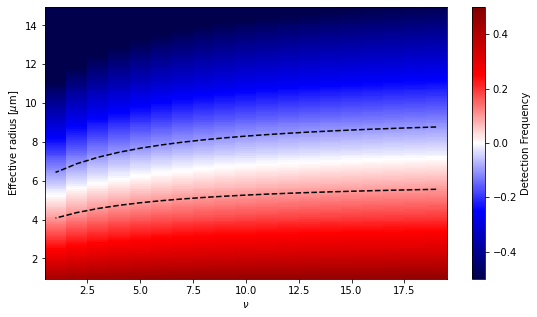

In [56]:
nivel = 5
fig, axs = plt.subplots(figsize=(9,5))
f0 = axs.pcolormesh(range_nu, 
                    range_radius, 
                    result_test[nivel],
                    cmap='seismic', 
                    vmin=-.5,
                    vmax=.5)

contour = plt.contour(range_nu, range_radius, result_test[nivel], colors='black', linestyles='dashed', levels = [-.1, .1,])
axs.set_ylabel(r'Effective radius [$\mu$m]')
axs.set_xlabel(r'$\nu$')
#axs.set_ylim([z_min,z_max])
fig.colorbar(f0, label='Detection Frequency')
plt.show()